## Import Data

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB

# Setup style visualisasi (opsional tapi bagus)
sns.set(style="whitegrid")

## Data Understanding

In [11]:
# Load dataset
titanic_data = pd.read_csv('../data/tested.csv')

# Menampilkan 5 data teratas dan terbawah
print("Head:")
print(titanic_data.head())
print("\nTail:")
print(titanic_data.tail())

# Melihat dimensi data (baris, kolom)
print("\nShape:", titanic_data.shape)

# Cek info tipe data dan missing value
print("\nInfo Dataset:")
titanic_data.info()

# Cek jumlah missing value per kolom
print("\nJumlah Missing Values:")
print(titanic_data.isnull().sum())

Head:
   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   

    Ticket     Fare Cabin Embarked  
0   330911   7.8292   NaN        Q  
1   363272   7.0000   NaN        S  
2   240276   9.6875   NaN        Q  
3   315154   8.6625   NaN        S  
4  3101298  12.2875   NaN        S  

Tail:
     PassengerId  Survived  Pclass                          Name     Sex 

## Data Cleaning

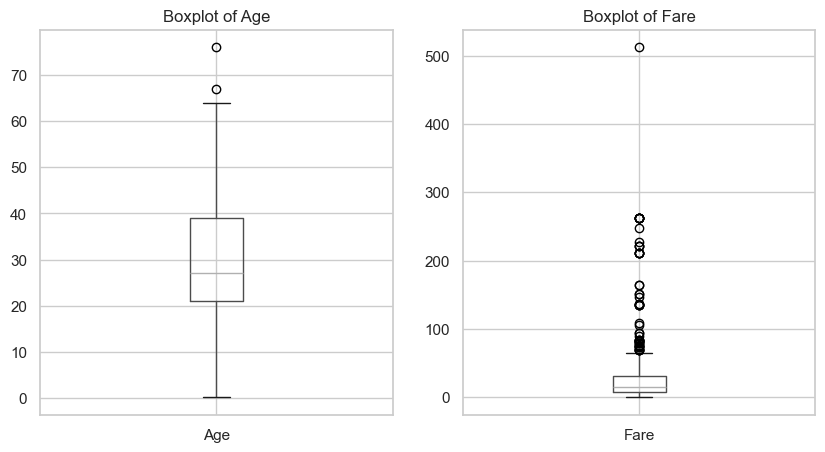


Sisa Missing Values setelah cleaning:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [12]:
# 1. Menghapus kolom yang tidak relevan (banyak missing atau id unik)
titanic_data.drop(columns=['PassengerId', 'Cabin', 'Name', 'Ticket'], axis=1, inplace=True)

# 2. Cek outlier (Opsional, untuk visualisasi)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
titanic_data.boxplot(column=['Age'])
plt.title("Boxplot of Age")

plt.subplot(1, 2, 2)
titanic_data.boxplot(column=['Fare'])
plt.title("Boxplot of Fare")
plt.show()

# 3. Mengisi Missing Values dengan Median (karena lebih tahan outlier)
titanic_data['Age'] = titanic_data['Age'].fillna(titanic_data['Age'].median())
titanic_data['Fare'] = titanic_data['Fare'].fillna(titanic_data['Fare'].median())

# Cek ulang apakah sudah bersih
print("\nSisa Missing Values setelah cleaning:")
print(titanic_data.isnull().sum())

## Visualisazion

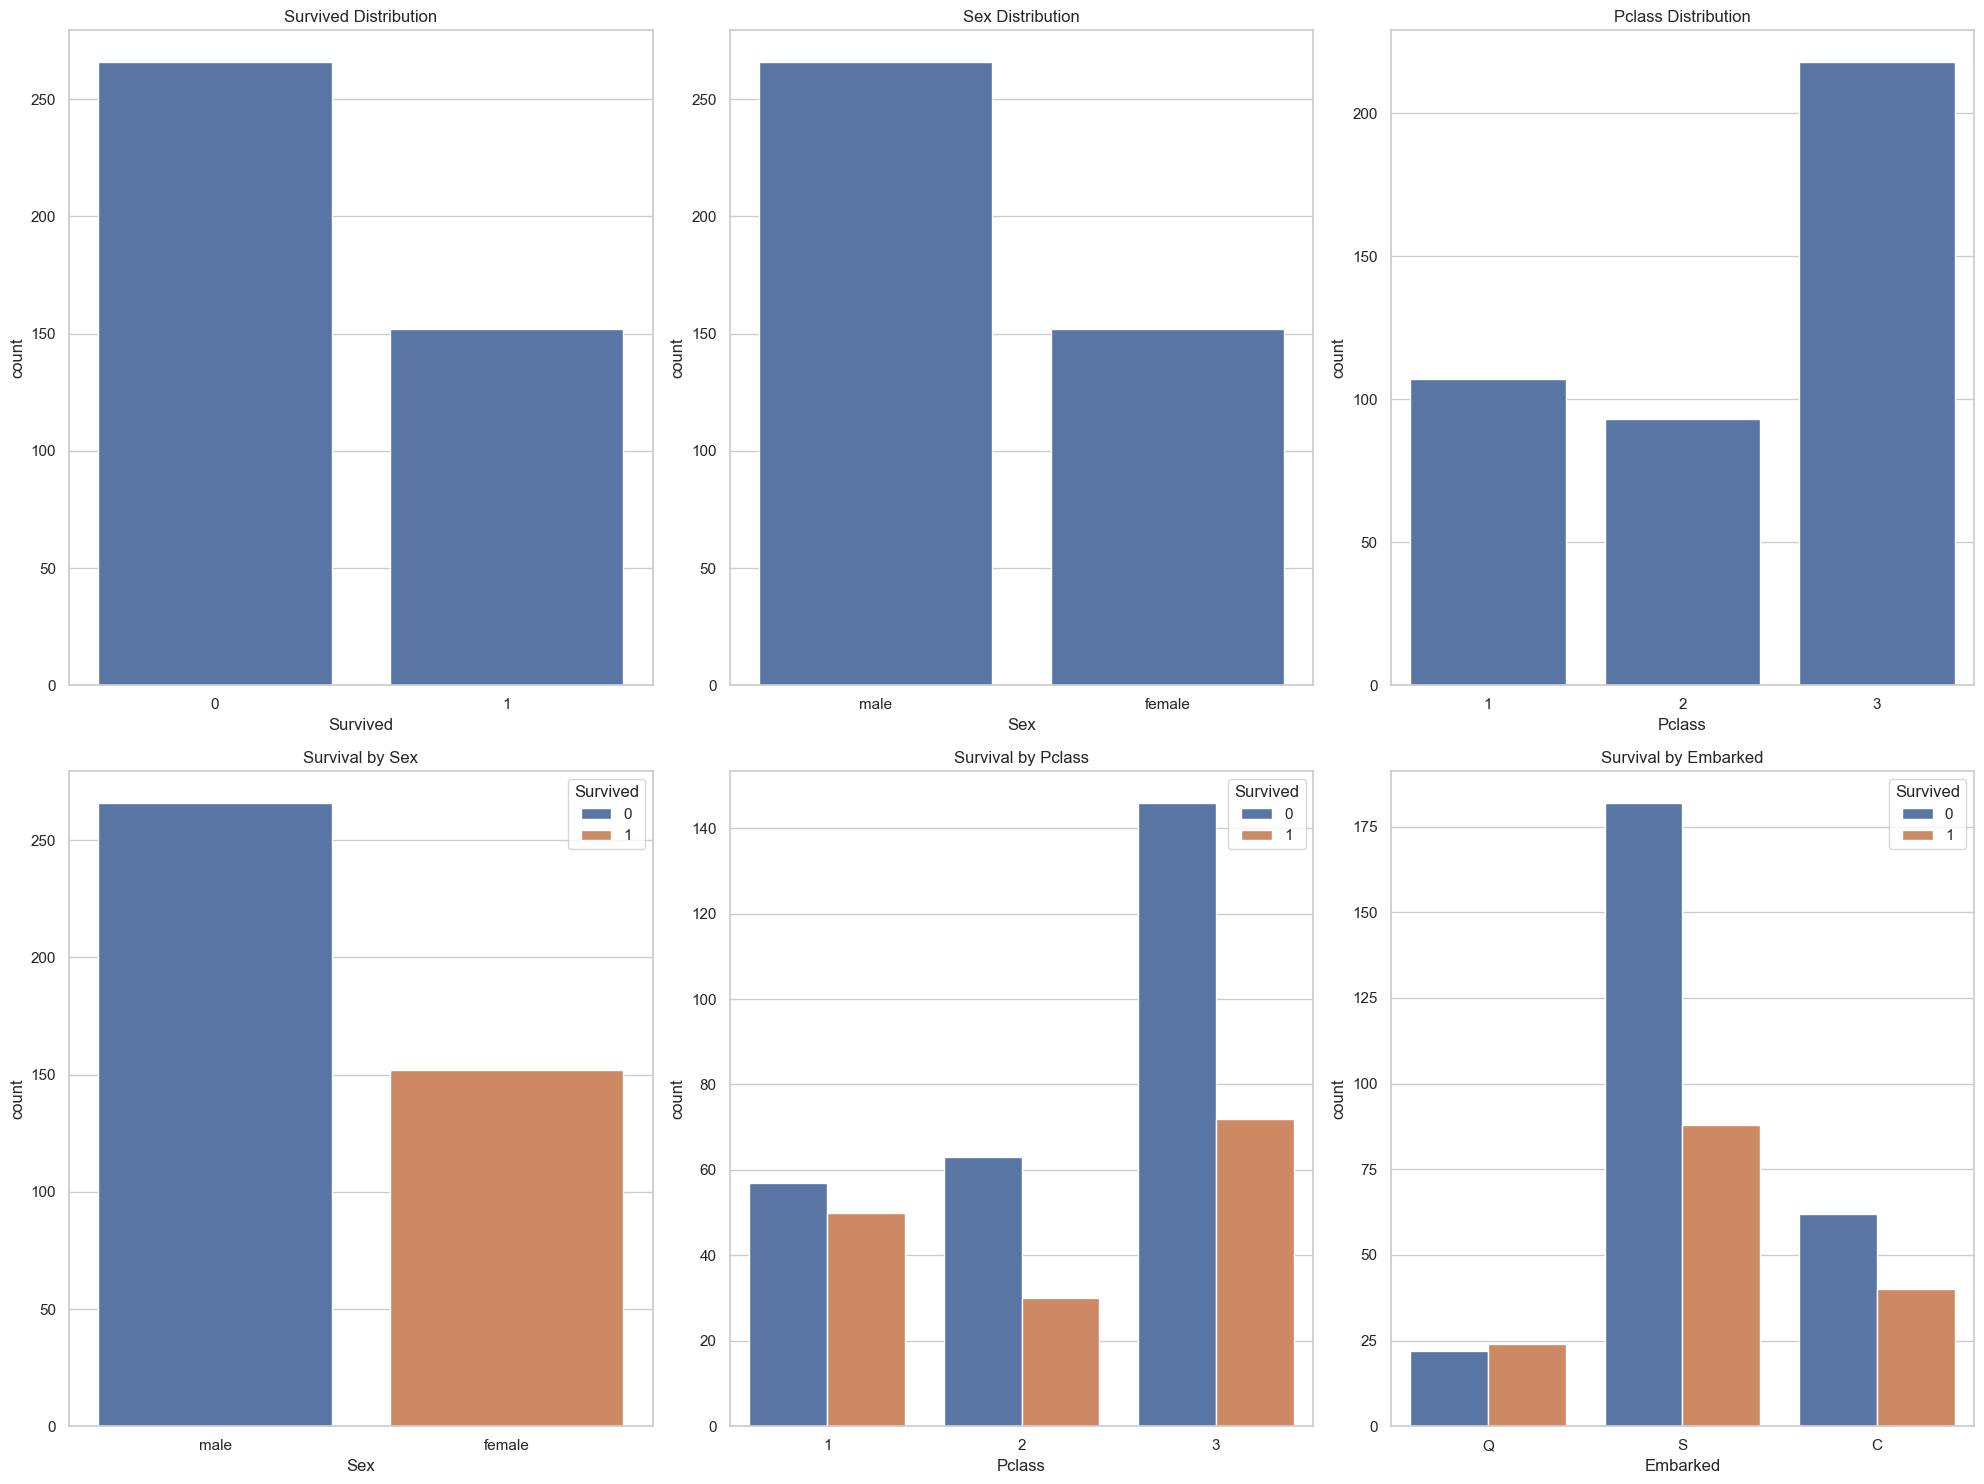

In [13]:
# Membuat visualisasi subplot
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 15))
axes = axes.flatten()

# Plot data
sns.countplot(x='Survived', data=titanic_data, ax=axes[0])
axes[0].set_title('Survived Distribution')

sns.countplot(x='Sex', data=titanic_data, ax=axes[1])
axes[1].set_title('Sex Distribution')

sns.countplot(x='Pclass', data=titanic_data, ax=axes[2])
axes[2].set_title('Pclass Distribution')

sns.countplot(x='Sex', hue='Survived', data=titanic_data, ax=axes[3])
axes[3].set_title('Survival by Sex')

sns.countplot(x='Pclass', hue='Survived', data=titanic_data, ax=axes[4])
axes[4].set_title('Survival by Pclass')

sns.countplot(x='Embarked', hue='Survived', data=titanic_data, ax=axes[5])
axes[5].set_title('Survival by Embarked')

plt.tight_layout()
plt.show()

## Data Transform

In [15]:
# Konversi data kategori ke numerik
replacements = {
    'Sex': {'male': 0, 'female': 1},
    'Embarked': {'S': 0, 'C': 1, 'Q': 2}
}
pd.set_option('future.no_silent_downcasting', True)

titanic_data = titanic_data.replace(replacements).infer_objects(copy=False)

# Cek hasil perubahan
print(titanic_data.head())

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    0  34.5      0      0   7.8292         2
1         1       3    1  47.0      1      0   7.0000         0
2         0       2    0  62.0      0      0   9.6875         2
3         0       3    0  27.0      0      0   8.6625         0
4         1       3    1  22.0      1      1  12.2875         0


## Create Model

In [16]:
# Pisahkan Fitur (X) dan Target (Y)
X = titanic_data.drop(columns=['Survived'])
Y = titanic_data['Survived']

# Split data: 80% Training, 20% Testing
# stratify=Y memastikan proporsi yang selamat/tidak seimbang di kedua set
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

print(f"Shape X: {X.shape}")
print(f"Shape Train: {X_train.shape}")
print(f"Shape Test: {X_test.shape}")

# Scaling (Standarisasi data agar skalanya sama)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Shape X: (418, 7)
Shape Train: (334, 7)
Shape Test: (84, 7)


In [17]:
# Inisialisasi dan Training Model
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, Y_train)

# Melakukan Prediksi
train_pred_nb = nb_model.predict(X_train_scaled)
test_pred_nb = nb_model.predict(X_test_scaled)

# Cek Akurasi
print("Training Accuracy (NB):", accuracy_score(Y_train, train_pred_nb))
print("Testing Accuracy (NB):", accuracy_score(Y_test, test_pred_nb))

Training Accuracy (NB): 1.0
Testing Accuracy (NB): 1.0


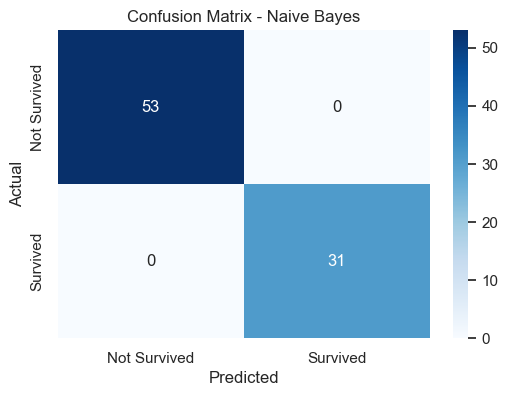


Classification Report (NB):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        31

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



In [18]:
# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 4))
cm_nb = confusion_matrix(Y_test, test_pred_nb)

sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])

plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report Lengkap
print("\nClassification Report (NB):")
print(classification_report(Y_test, test_pred_nb))

In [19]:
from sklearn.model_selection import cross_val_score

# Melakukan 5-Fold Cross Validation
cv_nb = cross_val_score(nb_model, X, Y, cv=5, scoring='accuracy')

print("\nNaive Bayes Cross Validation Accuracy (5-Fold):")
print("Scores:", cv_nb)
print("Mean Accuracy:", cv_nb.mean())
print("Std Deviation:", cv_nb.std())


Naive Bayes Cross Validation Accuracy (5-Fold):
Scores: [1. 1. 1. 1. 1.]
Mean Accuracy: 1.0
Std Deviation: 0.0
